#
# **Handwritten Character Recognition using CNN**

### **CodeAlpha Machine Learning Internship - Task 3**

**Intern Name:** Radhika

**Platform:** Google Colab

**Programming Language:** Machine Learning


## 📌 Project Objective

The objective of this project is to recognize handwritten digits using Deep Learning techniques. A Convolutional Neural Network (CNN) is used to classify handwritten digits from the MNIST dataset.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Load Dataset

The MNIST dataset contains handwritten digit images ranging from 0 to 9.

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


## Visualizing Sample Images

The following images represent handwritten digits from the dataset.

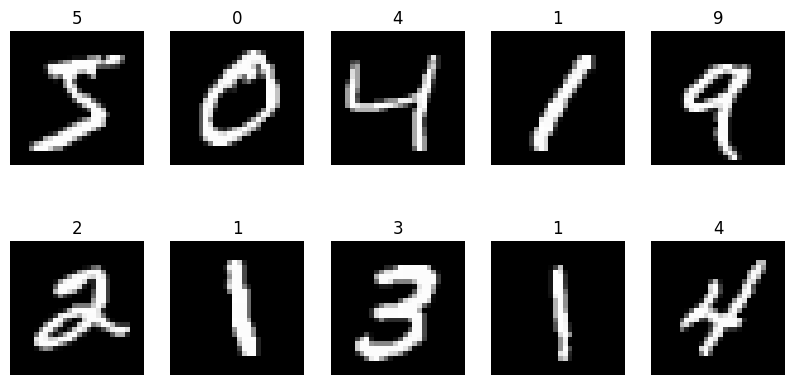

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

## Data Preprocessing

The image pixel values are normalized between 0 and 1 for efficient model training.

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(X_train.shape)

(60000, 28, 28, 1)


## Building CNN Model

A Convolutional Neural Network (CNN) is used to automatically learn image features and classify handwritten digits.

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Model
The CNN model is trained on the MNIST dataset.

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    validation_data=(X_test,y_test_cat)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9559 - loss: 0.1495 - val_accuracy: 0.9794 - val_loss: 0.0598
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9845 - loss: 0.0513 - val_accuracy: 0.9843 - val_loss: 0.0443
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9894 - loss: 0.0337 - val_accuracy: 0.9857 - val_loss: 0.0474
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9933 - loss: 0.0215 - val_accuracy: 0.9879 - val_loss: 0.0388
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9877 - val_loss: 0.0413


## Model Evaluation

After training the CNN model, the performance is evaluated on the test dataset.

The evaluation metrics include Test Loss and Test Accuracy, which indicate how well the model generalizes to unseen handwritten digit images.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9877 - loss: 0.0413
Test Loss: 0.04133414477109909
Test Accuracy: 0.9876999855041504


## Training and Validation Accuracy

The following graph shows the training accuracy and validation accuracy across different epochs.

A higher accuracy value indicates better model performance in recognizing handwritten digits.

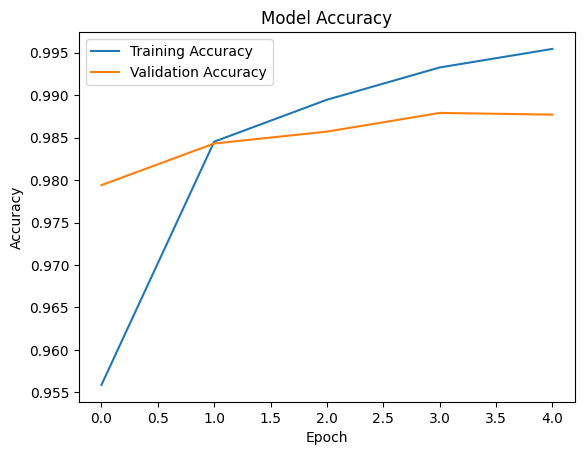

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy','Validation Accuracy'])

plt.show()

## Training and Validation Loss

The loss graph illustrates how the error decreases during the training process.

Lower loss values indicate improved learning and better model optimization.

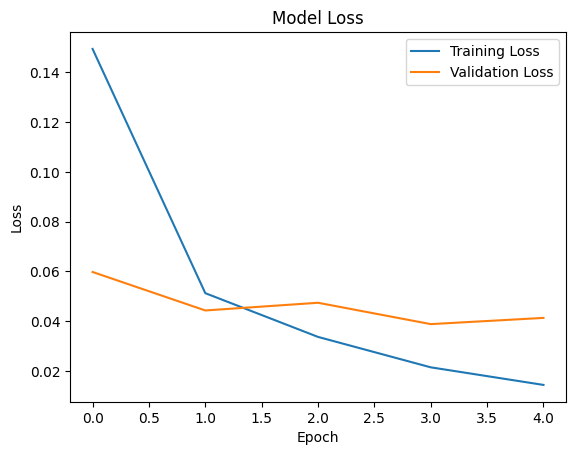

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss','Validation Loss'])

plt.show()

## Prediction on Test Images

The trained CNN model is used to predict handwritten digits from the test dataset.

The predicted output is compared visually with the input images to verify model performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


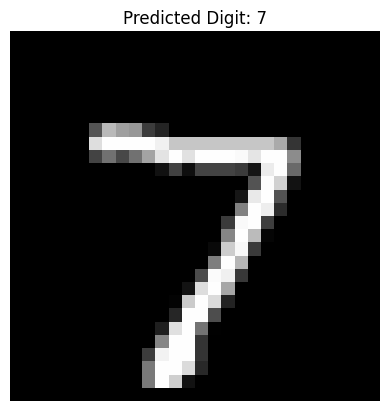

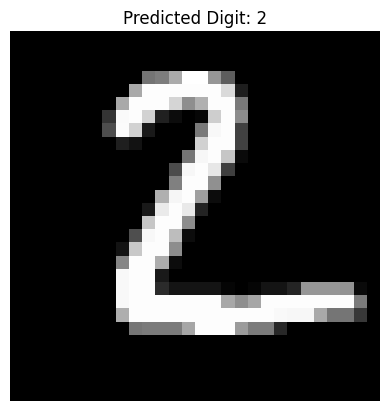

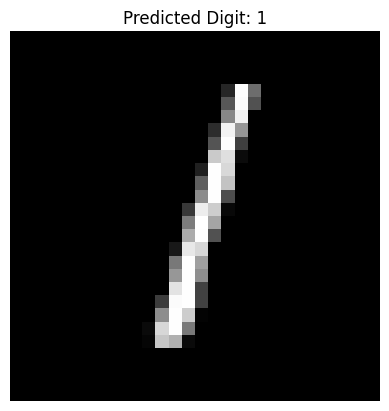

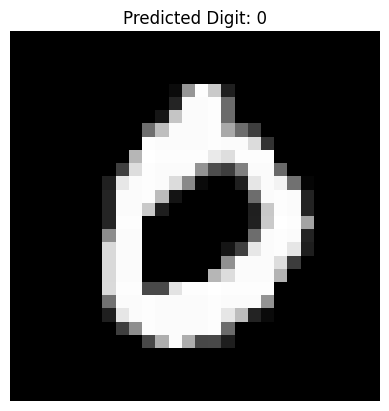

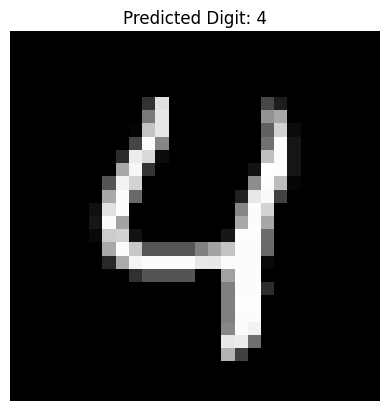

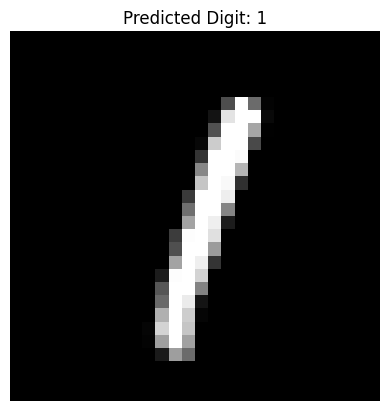

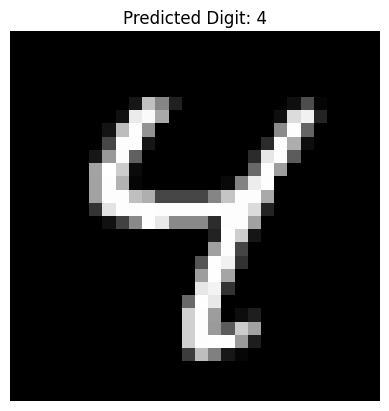

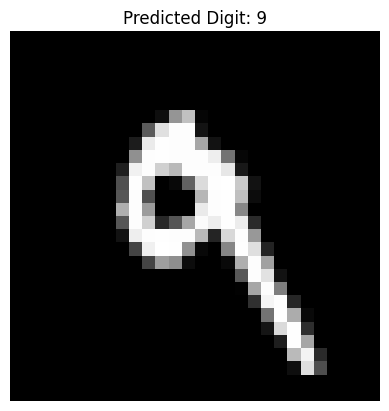

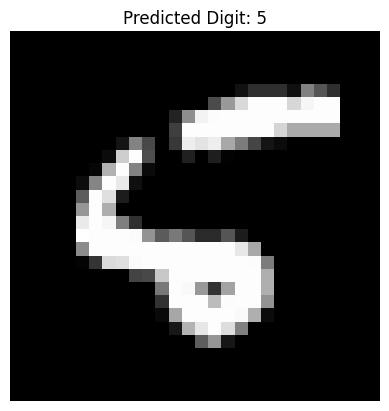

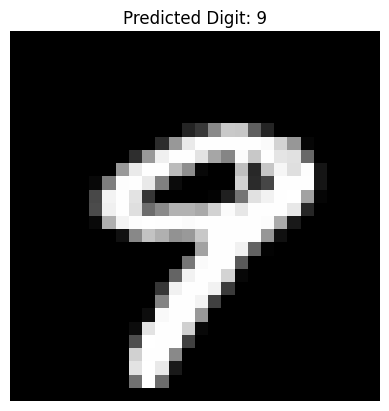

In [ ]:
predictions = model.predict(X_test[:10])

for i in range(10):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted Digit: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()

## Confusion Matrix

A confusion matrix is used to evaluate the classification performance of the CNN model.

It displays the number of correct and incorrect predictions for each digit class and helps identify misclassification patterns.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


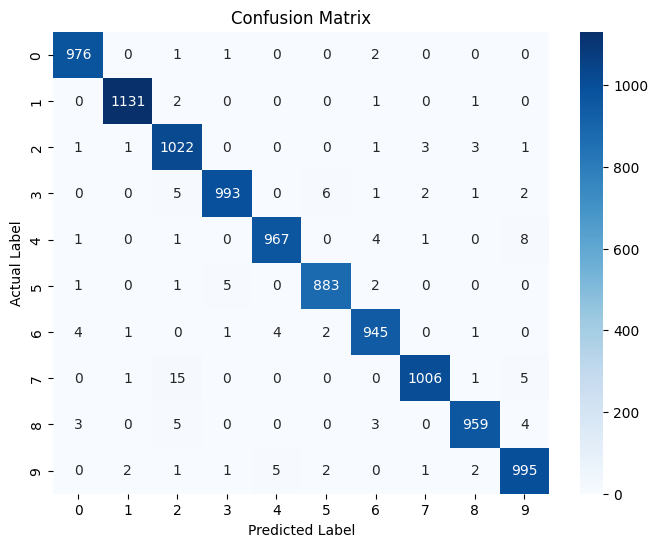

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

plt.show()

## Results Analysis

The CNN model achieved excellent performance on the MNIST handwritten digit dataset.

Key Findings:

• Test Accuracy achieved: 98.77%

• Test Loss achieved: 0.0413

• Training Accuracy reached above 99%

• Validation Accuracy remained stable around 98%

The confusion matrix shows that most digits were classified correctly. Only a few samples were misclassified, mainly between visually similar digits.

These results indicate that the CNN model successfully learned important image features and generalized well on unseen handwritten digit images.

## Advantages of Convolutional Neural Networks

• Automatically extracts image features.

• Requires less manual feature engineering.

• High accuracy for image classification tasks.

• Efficient for handwritten character recognition.

• Robust against small variations in handwriting style.

## Applications of Handwritten Character Recognition

• Bank cheque processing

• Postal code recognition

• Automatic form processing

• Digitization of historical documents

• Educational assessment systems

• OCR (Optical Character Recognition)

• License plate recognition

##Future Scope

The performance of the current model can be further improved by:

• Using deeper CNN architectures.

• Applying data augmentation techniques.

• Training on larger handwritten character datasets.

• Extending the model to recognize alphabets and special symbols.

• Deploying the model as a web application using Flask or Streamlit.

## Project Summary

This project demonstrates the implementation of a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset.

The dataset was preprocessed, normalized, and used to train a deep learning model. The trained CNN achieved approximately 98.77% test accuracy, demonstrating strong classification performance.

Performance evaluation was conducted using accuracy curves, loss curves, sample predictions, and a confusion matrix.

The project highlights the effectiveness of deep learning techniques for image classification and optical character recognition applications.

# Conclusion

This project successfully demonstrates the implementation of a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset.

The dataset was preprocessed through normalization and reshaping techniques before training the model. A deep learning architecture consisting of convolutional, pooling, and dense layers was developed to classify handwritten digits from 0 to 9.

The trained model achieved approximately 98.77% test accuracy, indicating strong classification performance and effective feature extraction capabilities. The confusion matrix further confirmed that the majority of digits were correctly classified, with only a small number of misclassifications occurring between visually similar digits.

Overall, the project highlights the effectiveness of Convolutional Neural Networks in image classification and Optical Character Recognition (OCR) tasks. The developed model can serve as a foundation for more advanced handwritten character recognition systems and real-world document digitization applications.

# References

1. LeCun, Y., Cortes, C., & Burges, C. J. C. (1998). MNIST Handwritten Digit Database.
   http://yann.lecun.com/exdb/mnist/

2. TensorFlow Documentation.
   https://www.tensorflow.org/

3. Keras Documentation.
   https://keras.io/

4. Scikit-Learn Documentation.
   https://scikit-learn.org/

5. Chollet, F. (2021). Deep Learning with Python. Manning Publications.